# KMeans clustering analysis

Same deduplication procedure as `dec_clustering_analysis.ipynb` (neurons that are the same
physical cell imaged across adjacent z-planes are merged based on 3D position + response
correlation), but instead of loading cluster labels from a DEC/KL training run's saved
`predicted` field, KMeans is fit live on the readout embeddings of the plain (non-DEC)
`gaussian_retina_mean_more_data` sweep (`sensorium/training/runs/gaussian_retina_mean_more_data`,
one run per seed). We also compute kNN consistency of the raw embeddings across seeds, which
has no DEC-notebook analogue since there was no need for it there (cluster labels were already
loaded, not derived from embeddings). `KMeans` clustering and kNN-consistency helpers are
imported from `utils.py` (`get_ari_curve`, `get_knn_curve`), the same module `evaluate.ipynb`
uses for its own kNN-consistency curve.

Embeddings are whitened before clustering/kNN exactly when the run's checkpoint has a
`whitener.*` buffer (i.e. `whitener=True` was passed to `stacked_core_gaussian_retina_mean_readout`
during training) -- this is checked per run rather than assumed.

In [1]:
import os
import pickle
from collections import Counter
from itertools import combinations

import numpy as np
import torch
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

from utils import get_ari_curve, get_knn_curve


In [2]:
# ---- sweep config (ARI/kNN-vs-embedding analysis) ----
SEEDS = [42, 83, 101, 311, 569]
CLUSTER_NUMBERS = [5, 10, 15, 20, 25, 30, 40, 50, 60]
RUNS_DIR = os.path.join('..', 'training', 'runs', 'gaussian_retina_mean_more_data')

# ---- t-SNE config (single representative run) ----
TSNE_SEED = 42
TSNE_CLUSTER_NUMBER = 30

DATA_HASH = '94c6ff995dac583098847cfecd43e7b6'


def run_dir_for(seed):
    return os.path.join(RUNS_DIR, f'seed{seed}')


# some seeds in the sweep may still be training (no model_weights.pth yet) -- skip those
# rather than failing, since we never want to touch/kill a running job to "fix" this
available_seeds = [s for s in SEEDS if os.path.exists(os.path.join(run_dir_for(s), 'model_weights.pth'))]
missing_seeds = sorted(set(SEEDS) - set(available_seeds))
if missing_seeds:
    print(f'skipping seeds with no saved checkpoint yet (still training/failed): {missing_seeds}')
SEEDS = available_seeds
assert TSNE_SEED in SEEDS, f'TSNE_SEED={TSNE_SEED} has no checkpoint yet'
print(f'using seeds: {SEEDS}')


skipping seeds with no saved checkpoint yet (still training/failed): [569]
using seeds: [42, 83, 101, 311]


## 1. Discover session order and per-session neuron counts

`readout.<session_id>._features` in `model_weights.pth` is an insertion-ordered `ModuleDict`,
so we can recover the session order and per-session neuron counts directly from any run's
checkpoint without rebuilding the model or dataloaders. This is computed once and reused for
every run, since all seeds in the sweep share the same dataset/model architecture (only the
seed differs).

In [3]:
def get_session_order_and_sizes(run_dir):
    state_dict = torch.load(os.path.join(run_dir, 'model_weights.pth'), map_location='cpu')
    session_ids, sizes = [], []
    for key, value in state_dict.items():
        if key.startswith('readout.') and key.endswith('._features'):
            session_ids.append(key[len('readout.'):-len('._features')])
            sizes.append(value.shape[0])
    return session_ids, sizes


animals, session_sizes = get_session_order_and_sizes(run_dir_for(SEEDS[0]))
session_offsets = np.cumsum([0] + session_sizes)
n_neurons_total = int(session_offsets[-1])
print(f'{len(animals)} sessions, {n_neurons_total} neurons total')

# sanity check: a different seed's run has the identical session order/sizes, since only the
# trained weights differ, not the architecture
if len(SEEDS) > 1:
    other_animals, other_sizes = get_session_order_and_sizes(run_dir_for(SEEDS[-1]))
    assert animals == other_animals and session_sizes == other_sizes


11 sessions, 77709 neurons total


## 2. Per-animal deduplication

Ported as-is from `dec_clustering_analysis.ipynb` (`dedup_animal`, `RADIUS = 4`,
`CORR_THRESHOLD = 0.8`): for each neuron, walk outward through z-planes in both directions,
picking the laterally-nearest neuron at each step, stopping the chain once lateral drift
exceeds `RADIUS` or response correlation drops to `<= CORR_THRESHOLD`; neurons linked this way
are merged transitively (union-find) into duplicate groups. This depends only on the dataset
(coordinates + responses), not on any trained model, so it is computed once per animal and
reused for every seed below.

`BASE_CANDIDATES` points at the dataset paths `training/train.py` actually used to build this
sweep's dataloaders (`--more_data`), which differ from the paths `dec_clustering_analysis.ipynb`
uses for its own (older) runs.

In [4]:
# dataset paths training/train.py uses (with --more_data) to build this sweep's dataloaders
BASE_CANDIDATES = [
    ('/user/turishcheva/nathans_code/sensorium_original', '-GrayImageNet-'),
    ('/user/turishcheva/nathans_code/more_data_like_sensorium', '-'),
]


def resolve_session_dir(session_id):
    for base, link in BASE_CANDIDATES:
        candidate = os.path.join(base, f'static{session_id}{link}{DATA_HASH}')
        if os.path.isdir(candidate):
            return candidate
    raise FileNotFoundError(f'Could not find a data directory for session {session_id}')


def load_coords(session_id):
    return np.load(os.path.join(
        resolve_session_dir(session_id), 'meta', 'neurons', 'cell_motor_coordinates.npy'
    ))


def load_responses(session_id):
    path = os.path.join(resolve_session_dir(session_id), 'data', 'responses')
    n = len(os.listdir(path))
    return np.vstack([np.load(os.path.join(path, f'{j}.npy')) for j in range(n)]).T  # (neurons, images)


In [5]:
RADIUS = 4
CORR_THRESHOLD = 0.8


def dedup_animal(coords_a, responses_a):
    n = len(coords_a)
    def corr(x, y):
        x = x - x.mean(); y = y - y.mean()
        return np.dot(x, y) / np.sqrt(np.dot(x, x) * np.dot(y, y))

    def walk_z(planes, z_order, target_resp, prev_xy):
        copies = []
        for z in z_order:
            gidx, x, y = min(planes[z], key=lambda t: abs(t[1]-prev_xy[0]) + abs(t[2]-prev_xy[1]))
            if abs(x-prev_xy[0]) > RADIUS or abs(y-prev_xy[1]) > RADIUS:
                break
            if corr(target_resp, responses_a[gidx]) <= CORR_THRESHOLD:
                break
            copies.append(gidx)
            prev_xy = (x, y)
        return copies

    planes = {}
    for g in range(n):
        x, y, z = coords_a[g]
        planes.setdefault(z, []).append((g, x, y))
    sorted_z = sorted(planes)

    copy_dict = {}
    for g in range(n):
        x, y, z = coords_a[g]
        target = responses_a[g]
        up   = [zz for zz in sorted_z if zz > z]
        down = [zz for zz in sorted_z if zz < z][::-1]
        copies = walk_z(planes, up, target, (x, y)) + walk_z(planes, down, target, (x, y))
        if copies:
            copy_dict[g] = copies

    parent = {}
    def find(x):
        parent.setdefault(x, x)
        while parent[x] != x:
            parent[x] = parent[parent[x]]; x = parent[x]
        return x
    def union(a, b):
        parent[find(a)] = find(b)
    for neuron, copies in copy_dict.items():
        for c in copies:
            union(neuron, c)

    groups = {}
    for node in parent:
        groups.setdefault(find(node), set()).add(node)
    unique_groups = list(groups.values())
    grouped = set().union(*unique_groups) if unique_groups else set()
    individual_neurons = sorted(set(range(n)) - grouped)
    return unique_groups, individual_neurons


In [6]:
coords_per_animal = {}
unique_groups_per_animal = {}
individual_neurons_per_animal = {}

for a, n_neurons in tqdm(list(zip(animals, session_sizes))):
    coords_a = load_coords(a)
    responses_a = load_responses(a)
    assert len(coords_a) == len(responses_a) == n_neurons, (
        f'{a}: coords/responses neuron count does not match checkpoint ({len(coords_a)} vs {n_neurons})'
    )
    unique_groups, individual_neurons = dedup_animal(coords_a, responses_a)
    coords_per_animal[a] = coords_a
    unique_groups_per_animal[a] = unique_groups
    individual_neurons_per_animal[a] = individual_neurons
    print(f'{a}: {n_neurons} neurons -> {len(individual_neurons)} individual + {len(unique_groups)} duplicate groups')


  9%|▉         | 1/11 [00:09<01:30,  9.10s/it]

23656-14-22: 8107 neurons -> 1668 individual + 2071 duplicate groups


 18%|█▊        | 2/11 [00:18<01:22,  9.15s/it]

21067-10-18: 8372 neurons -> 1791 individual + 1852 duplicate groups


 27%|██▋       | 3/11 [00:26<01:08,  8.60s/it]

...

22564-2-12: 8115 neurons -> 8033 individual + 40 duplicate groups


 91%|█████████ | 10/11 [01:04<00:05,  5.51s/it]

22620-4-15: 7957 neurons -> 1437 individual + 2009 duplicate groups


100%|██████████| 11/11 [01:09<00:00,  6.35s/it]

23555-5-12: 6559 neurons -> 1734 individual + 1444 duplicate groups


## 3. Loading and (conditionally) whitening readout embeddings

`readout.<session_id>._features` in each run's `model_weights.pth` is the readout embedding
matrix for that session, shape `(n_neurons, n_channels)` -- no reshaping needed (unlike
`FullGaussian2d`'s `(1, C, 1, N)` features used in `evaluate.ipynb`, `GaussianRetinaMean`
already stores its `_features` as `(N, C)`).

A run's embeddings are whitened with its own `whitener.cov_ema` (via `transform_weights`, ported
from `neuralpredictors.layers.whiteners.Whitener`) exactly when that key exists in its checkpoint,
i.e. exactly when `whitener=True` was passed for that training run -- checked per run rather than
assumed to be on/off for the whole sweep.

Dedup groups are reduced by **mean** (not majority vote, since embeddings are continuous), same
as the t-SNE section of `dec_clustering_analysis.ipynb`.

In [7]:
def whiten_readouts(cov_ema, readouts, eps=1e-5):
    eye = torch.eye(cov_ema.shape[0], dtype=cov_ema.dtype, device='cpu')
    L = torch.linalg.cholesky(cov_ema + eps * eye)
    whitened_readouts = L.T @ readouts.T
    return whitened_readouts.T


def load_state_dict(run_dir):
    return torch.load(os.path.join(run_dir, 'model_weights.pth'), map_location='cpu')


def get_animal_embeddings(state_dict):
    was_whitened = 'whitener.cov_ema' in state_dict
    cov_ema = state_dict.get('whitener.cov_ema')
    embeddings = {}
    for a in animals:
        feats = state_dict[f'readout.{a}._features'].squeeze()
        if was_whitened:
            feats = whiten_readouts(cov_ema, feats)
        embeddings[a] = feats.numpy()
    return embeddings, was_whitened


def reduce_by_mean(values_a, unique_groups, individual_neurons):
    individual = values_a[individual_neurons]
    if unique_groups:
        grouped = np.stack([values_a[list(g)].mean(0) for g in unique_groups])
    else:
        grouped = np.empty((0,) + values_a.shape[1:])
    return np.vstack([individual, grouped])


def load_reduced_embeddings_for_run(run_dir):
    state_dict = load_state_dict(run_dir)
    animal_embeddings, was_whitened = get_animal_embeddings(state_dict)
    reduced = [
        reduce_by_mean(animal_embeddings[a], unique_groups_per_animal[a], individual_neurons_per_animal[a])
        for a in animals
    ]
    return np.vstack(reduced), was_whitened


In [32]:
def load_all_embeddings_for_run(run_dir):
    state_dict = load_state_dict(run_dir)
    animal_embeddings, was_whitened = get_animal_embeddings(state_dict)
    reduced = [
        animal_embeddings[a]
        for a in animals
    ]
    return np.vstack(reduced), was_whitened

In [33]:
all_features_with_duplicates = []
for seed in tqdm(SEEDS):
    feats, was_whitened = load_all_embeddings_for_run(run_dir_for(seed))
    all_features_with_duplicates.append(feats)

100%|██████████| 4/4 [00:00<00:00,  6.72it/s]


In [8]:
all_features = []
for seed in tqdm(SEEDS):
    feats, was_whitened = load_reduced_embeddings_for_run(run_dir_for(seed))
    all_features.append(feats)
    print(f'seed {seed}: {feats.shape}, whitened={was_whitened}')


 25%|██▌       | 1/4 [00:00<00:00,  3.05it/s]

seed 42: (40722, 96), whitened=True


 50%|█████     | 2/4 [00:00<00:00,  3.06it/s]

seed 83: (40722, 96), whitened=True


 75%|███████▌  | 3/4 [00:00<00:00,  3.32it/s]

seed 101: (40722, 96), whitened=True


100%|██████████| 4/4 [00:01<00:00,  3.20it/s]

seed 311: (40722, 96), whitened=True


## 4. ARI consistency across seeds vs. cluster count

For each cluster count, KMeans is fit independently on each seed's (deduped, conditionally
whitened) embeddings and the resulting labels are compared pairwise via Adjusted Rand Index
(ARI) -- the direct analogue of `dec_clustering_analysis.ipynb`'s ARI-vs-cluster-count curve,
except the labels come from a fresh KMeans fit here instead of a saved DEC training run.
`get_ari_curve` (from `utils.py`) does the KMeans fit + pairwise ARI internally.

In [19]:
CLUSTER_NUMBERS = np.unique(np.geomspace(2, 150, num=30, dtype=int))

In [20]:
ari_mean, ari_std = get_ari_curve(CLUSTER_NUMBERS, all_features)
ari_mean = np.array(ari_mean)
ari_std = np.array(ari_std)


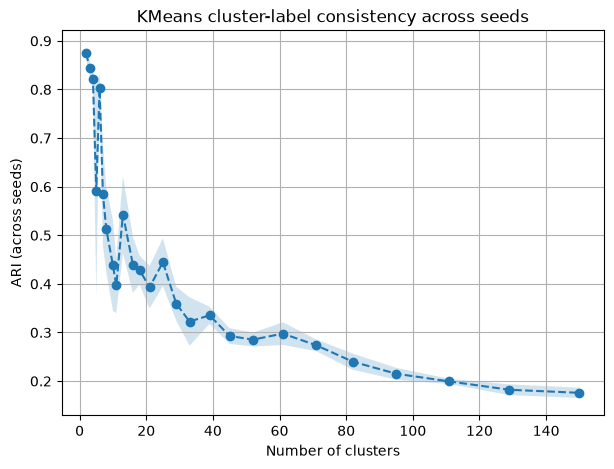

In [21]:
plt.figure(figsize=(7, 5))
plt.plot(CLUSTER_NUMBERS, ari_mean, ls='--', marker='o')
plt.fill_between(CLUSTER_NUMBERS, ari_mean - ari_std, ari_mean + ari_std, alpha=0.2)
plt.grid()
plt.xlabel('Number of clusters')
plt.ylabel('ARI (across seeds)')
plt.title('KMeans cluster-label consistency across seeds')
plt.show()


In [27]:
CLUSTER_NUMBERS[7:20]

array([10, 11, 13, 16, 18, 21, 25, 29, 33, 39, 45, 52, 61])

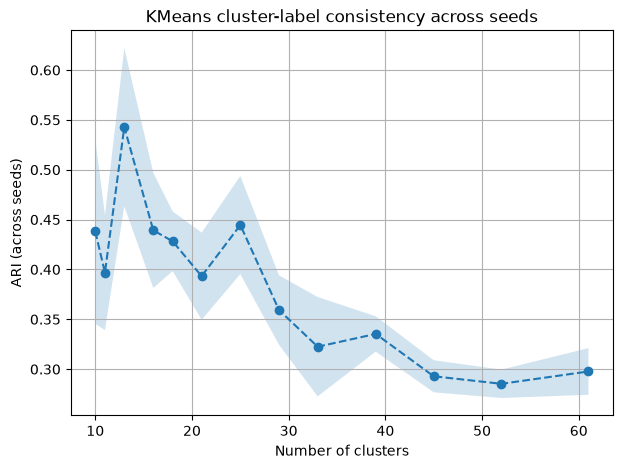

In [28]:
plt.figure(figsize=(7, 5))
plt.plot(CLUSTER_NUMBERS[7:20], ari_mean[7:20], ls='--', marker='o')
plt.fill_between(CLUSTER_NUMBERS[7:20], ari_mean[7:20] - ari_std[7:20], ari_mean[7:20] + ari_std[7:20], alpha=0.2)
plt.grid()
plt.xlabel('Number of clusters')
plt.ylabel('ARI (across seeds)')
plt.title('KMeans cluster-label consistency across seeds')
plt.show()


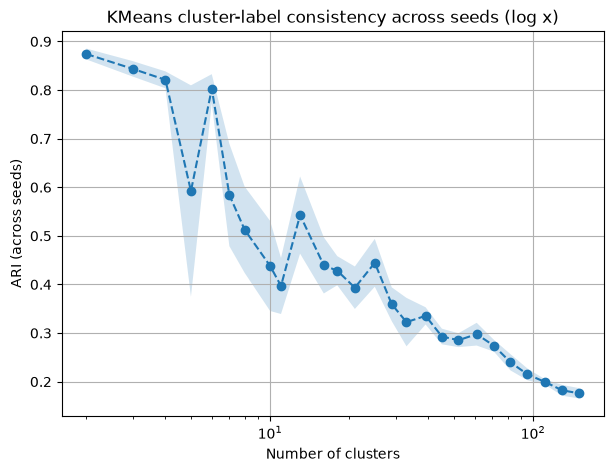

In [22]:
plt.figure(figsize=(7, 5))
plt.plot(CLUSTER_NUMBERS, ari_mean, ls='--', marker='o')
plt.fill_between(CLUSTER_NUMBERS, ari_mean - ari_std, ari_mean + ari_std, alpha=0.2)
plt.grid()
plt.xscale('log')
plt.xlabel('Number of clusters')
plt.ylabel('ARI (across seeds)')
plt.title('KMeans cluster-label consistency across seeds (log x)')
plt.show()


## 5. kNN consistency across seeds

For each neuron, its k nearest neighbours (by embedding distance) are computed independently
per seed, then compared pairwise across seeds: of the k neighbours a neuron has under seed A,
what fraction are still among its k neighbours under seed B. `get_knn_curve` (from `utils.py`,
the same helper `evaluate.ipynb` uses) does this over a geometric range of k. This has no
`dec_clustering_analysis.ipynb` analogue -- it operates directly on embeddings rather than on
cluster labels, so it needed the live embeddings this notebook already loads for KMeans/ARI.

In [12]:
(knn_mean, knn_std, _), k_range = get_knn_curve(all_features)


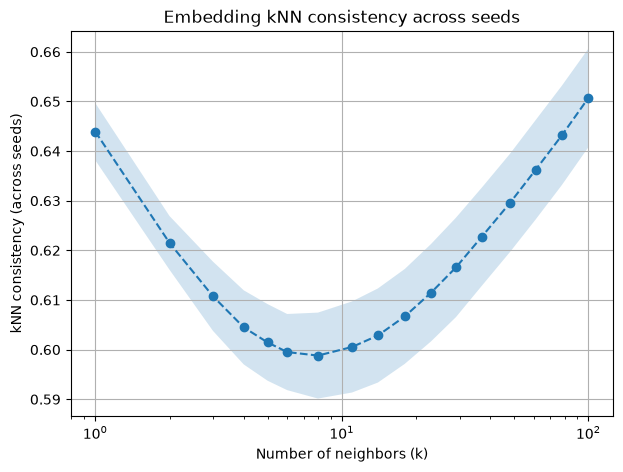

In [13]:
plt.figure(figsize=(7, 5))
plt.plot(k_range, knn_mean, ls='--', marker='o')
plt.fill_between(k_range, knn_mean - knn_std, knn_mean + knn_std, alpha=0.2)
plt.grid()
plt.xscale('log')
plt.xlabel('Number of neighbors (k)')
plt.ylabel('kNN consistency (across seeds)')
plt.title('Embedding kNN consistency across seeds')
plt.show()


In [34]:
(knn_mean_with_dup, knn_std_with_dup, _), k_range = get_knn_curve(all_features_with_duplicates)

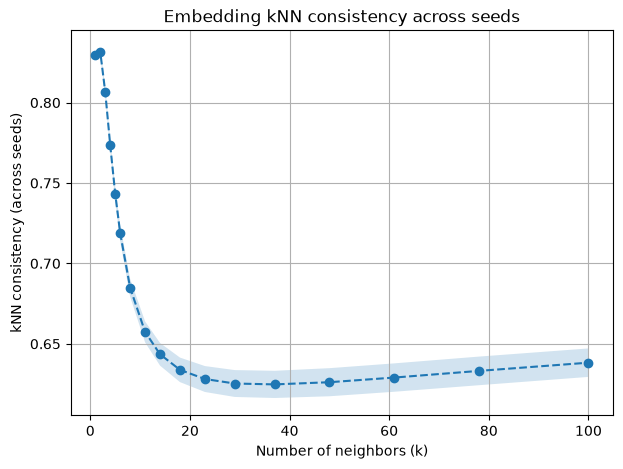

In [36]:
plt.figure(figsize=(7, 5))
plt.plot(k_range, knn_mean_with_dup, ls='--', marker='o')
plt.fill_between(k_range, knn_mean_with_dup - knn_std_with_dup, knn_mean_with_dup + knn_std_with_dup, alpha=0.2)
plt.grid()
# plt.xscale('log')
plt.xlabel('Number of neighbors (k)')
plt.ylabel('kNN consistency (across seeds)')
plt.title('Embedding kNN consistency across seeds')
plt.show()


## 6. t-SNE visualization for one representative run

Uses the (deduped, conditionally whitened) embeddings of `TSNE_SEED` already computed above and
a fresh KMeans fit with `TSNE_CLUSTER_NUMBER` clusters (instead of loading DEC labels from a
saved run, as `dec_clustering_analysis.ipynb` does). Positions are deduped the same way (mean
over each duplicate group).

In [14]:
tsne_idx = SEEDS.index(TSNE_SEED)
all_together_stacked = all_features[tsne_idx]

all_positions = [
    reduce_by_mean(coords_per_animal[a], unique_groups_per_animal[a], individual_neurons_per_animal[a])
    for a in animals
]
all_positions_stacked = np.vstack(all_positions)

mice_ids = np.concatenate([
    np.full(len(unique_groups_per_animal[a]) + len(individual_neurons_per_animal[a]), idx)
    for idx, a in enumerate(animals)
])

kmeans = KMeans(n_clusters=TSNE_CLUSTER_NUMBER, random_state=42)
all_labels_stacked = kmeans.fit_predict(all_together_stacked)

all_together_stacked.shape


(40722, 96)

In [15]:
X_embedded = TSNE(n_components=2).fit_transform(all_together_stacked)


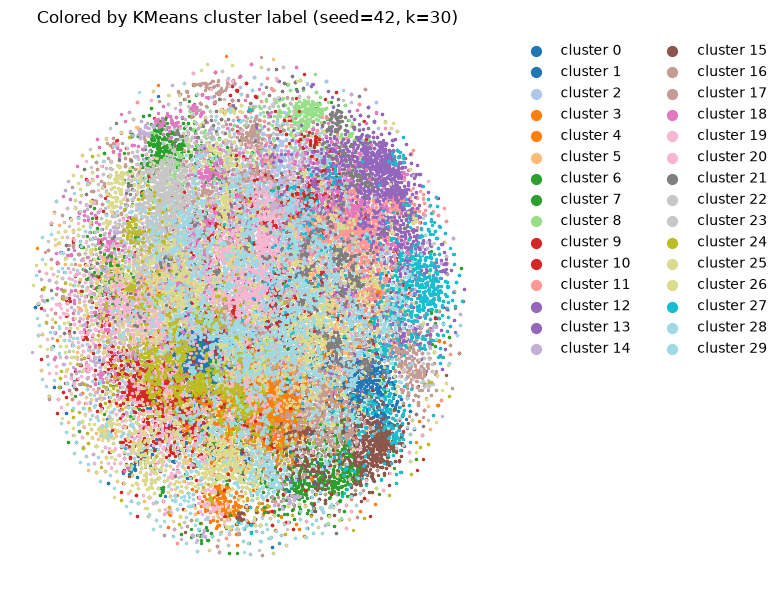

In [16]:
plt.figure(figsize=(8, 6))
unique_labels = np.unique(all_labels_stacked)
colors = plt.cm.tab20(np.linspace(0, 1, max(len(unique_labels), 2)))
for cluster_id, color in zip(unique_labels, colors):
    mask = all_labels_stacked == cluster_id
    plt.scatter(X_embedded[mask, 0], X_embedded[mask, 1], s=2, color=color, label=f'cluster {cluster_id}')
plt.xticks([]); plt.yticks([])
for spine in plt.gca().spines.values():
    spine.set_visible(False)
plt.legend(frameon=False, bbox_to_anchor=(1.05, 1), loc='upper left', markerscale=5, ncol=2)
plt.title(f'Colored by KMeans cluster label (seed={TSNE_SEED}, k={TSNE_CLUSTER_NUMBER})')
plt.tight_layout()
plt.show()


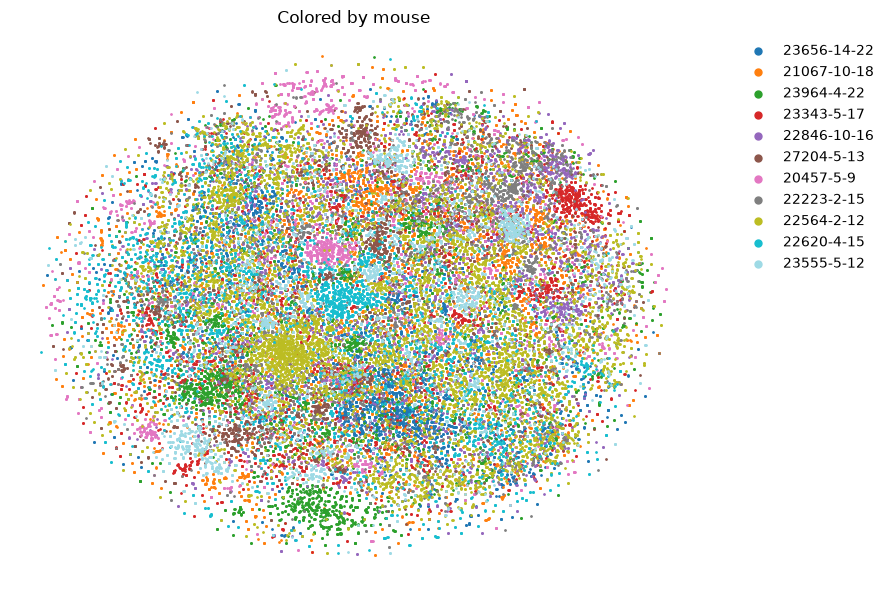

In [17]:
plt.figure(figsize=(9, 6))
colors = plt.cm.tab20(np.linspace(0, 1, len(np.unique(mice_ids))))
for mouse_id, color in zip(np.unique(mice_ids), colors):
    mask = mice_ids == mouse_id
    plt.scatter(X_embedded[mask, 0], X_embedded[mask, 1], s=1, color=color, label=animals[mouse_id])
plt.xticks([]); plt.yticks([])
for spine in plt.gca().spines.values():
    spine.set_visible(False)
plt.legend(frameon=False, bbox_to_anchor=(1.05, 1), loc='upper left', markerscale=5)
plt.title('Colored by mouse')
plt.tight_layout()
plt.show()


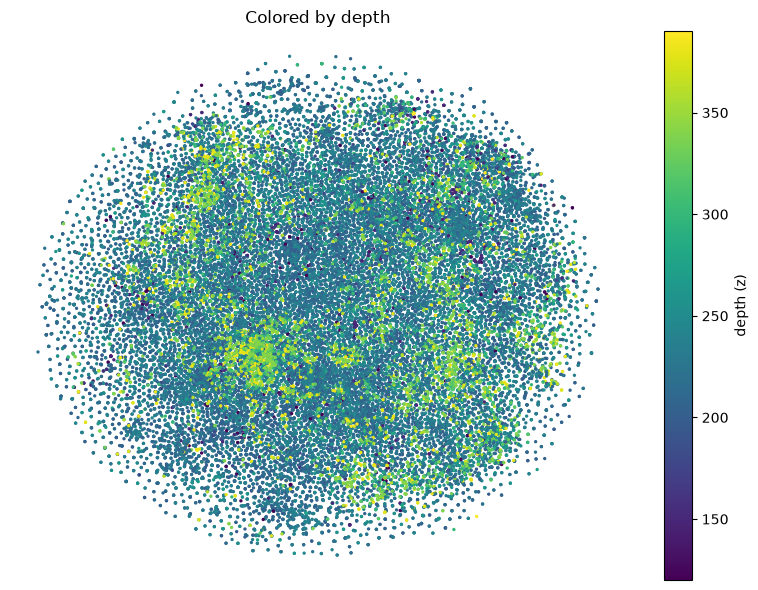

In [18]:
plt.figure(figsize=(8, 6))
z = all_positions_stacked[:, 2]
sc = plt.scatter(X_embedded[:, 0], X_embedded[:, 1], s=2, c=z, cmap='viridis')
plt.xticks([]); plt.yticks([])
for spine in plt.gca().spines.values():
    spine.set_visible(False)
plt.colorbar(sc, label='depth (z)')
plt.title('Colored by depth')
plt.tight_layout()
plt.show()
